[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MaxMitre/Mate_MercadosFinancieros/blob/main/Semana15_Modelo_de_Merton_para_riesgo.ipynb)

# Importaciones

In [ ]:
import pandas as pd
import datetime as dt
import numpy as np
import scipy.stats as st
from math import exp
import matplotlib.pyplot as plt
from matplotlib import style
import yfinance as yf
%matplotlib inline

style.use('ggplot')

# Data

In [ ]:
data = yf.download(  # or pdr.get_data_yahoo(...
        # tickers list or string as well
        # tickers = "GOOG AAPL IBM MSFT FB NFLX AMZN PLTR FSLY NET DDOG ZS SNOW",
        tickers = "AAPL ^GSPC, ^IRX",

        # use "period" instead of start/end
        # valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max
        # (optional, default is '1mo')
        period = "1y",

        # fetch data by interval (including intraday if period < 60 days)
        # valid intervals: 1m,2m,5m,15m,30m,60m,90m,1h,1d,5d,1wk,1mo,3mo
        # (optional, default is '1d')
        interval = "1d",

        # group by ticker (to access via data['SPY'])
        # (optional, default is 'column')
        # group_by = 'ticker',
    ).loc[:, 'Adj Close'].dropna()
data

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,^GSPC,^IRX
Date,,,
2023-11-02 00:00:00+00:00,176.666000,4317.779785,5.270
2023-11-03 00:00:00+00:00,175.750656,4358.339844,5.253
2023-11-06 00:00:00+00:00,178.317535,4365.979980,5.260
2023-11-07 00:00:00+00:00,180.894348,4378.379883,5.273
2023-11-08 00:00:00+00:00,181.958878,4382.779785,5.268
...,...,...,...
2024-10-28 00:00:00+00:00,233.399994,5823.520020,4.482
2024-10-29 00:00:00+00:00,233.669998,5832.919922,4.480
2024-10-30 00:00:00+00:00,230.100006,5813.669922,4.463


In [ ]:
data = data.tz_localize(None)
data

Ticker,AAPL,^GSPC,^IRX
Date,,,
2023-11-02,176.666000,4317.779785,5.270
2023-11-03,175.750656,4358.339844,5.253
2023-11-06,178.317535,4365.979980,5.260
2023-11-07,180.894348,4378.379883,5.273
2023-11-08,181.958878,4382.779785,5.268
...,...,...,...
2024-10-28,233.399994,5823.520020,4.482
2024-10-29,233.669998,5832.919922,4.480
2024-10-30,230.100006,5813.669922,4.463


In [ ]:
data["^IRX"] = data["^IRX"]/100
data

Ticker,AAPL,^GSPC,^IRX
Date,,,
2023-11-02,176.666000,4317.779785,0.05270
2023-11-03,175.750656,4358.339844,0.05253
2023-11-06,178.317535,4365.979980,0.05260
2023-11-07,180.894348,4378.379883,0.05273
2023-11-08,181.958878,4382.779785,0.05268
...,...,...,...
2024-10-28,233.399994,5823.520020,0.04482
2024-10-29,233.669998,5832.919922,0.04480
2024-10-30,230.100006,5813.669922,0.04463


In [ ]:
ticker = yf.Ticker("AAPL")

balance_sheet = ticker.quarterly_balance_sheet
balance_sheet

,2024-06-30,2024-03-31,2023-12-31,2023-09-30,2023-06-30,2023-03-31
Treasury Shares Number,NaN,NaN,0.0,0.0,NaN,NaN
Ordinary Shares Number,15222259000.0,15337686000.0,15460223000.0,15550061000.0,15647868000.0,NaN
Share Issued,15222259000.0,15337686000.0,15460223000.0,15550061000.0,15647868000.0,NaN
Net Debt,75739000000.0,71895000000.0,67280000000.0,81123000000.0,80872000000.0,NaN
Total Debt,101304000000.0,104590000000.0,108040000000.0,123930000000.0,109280000000.0,NaN
...,...,...,...,...,...,...
Cash Cash Equivalents And Short Term Investments,61801000000.0,67150000000.0,73100000000.0,61555000000.0,62482000000.0,NaN
Other Short Term Investments,36236000000.0,34455000000.0,32340000000.0,31590000000.0,34074000000.0,NaN
Cash And Cash Equivalents,25565000000.0,32695000000.0,40760000000.0,29965000000.0,28408000000.0,NaN
Cash Equivalents,2699000000.0,4468000000.0,11218000000.0,1606000000.0,3071000000.0,NaN


In [ ]:
balance_sheet = balance_sheet.loc['Total Liabilities Net Minority Interest',:]
balance_sheet

,Total Liabilities Net Minority Interest
2024-06-30,264904000000.0
2024-03-31,263217000000.0
2023-12-31,279414000000.0
2023-09-30,290437000000.0
2023-06-30,274764000000.0
2023-03-31,NaN


In [ ]:
balance_sheet = balance_sheet[:-1]/1_000_000_000
balance_sheet

,Total Liabilities Net Minority Interest
2024-06-30,264.904
2024-03-31,263.217
2023-12-31,279.414
2023-09-30,290.437
2023-06-30,274.764


In [ ]:
all_data = pd.concat([data, balance_sheet], axis=1)
all_data

,AAPL,^GSPC,^IRX,Total Liabilities Net Minority Interest
2023-06-30,NaN,NaN,NaN,274.764
2023-09-30,NaN,NaN,NaN,290.437
2023-11-02,176.666000,4317.779785,0.05270,NaN
2023-11-03,175.750656,4358.339844,0.05253,NaN
2023-11-06,178.317535,4365.979980,0.05260,NaN
...,...,...,...,...
2024-10-28,233.399994,5823.520020,0.04482,NaN
2024-10-29,233.669998,5832.919922,0.04480,NaN
2024-10-30,230.100006,5813.669922,0.04463,NaN
2024-10-31,225.910004,5705.450195,0.04432,NaN


In [ ]:
all_data.ffill(inplace=True)
all_data

<ipython-input-9-566389f35182>:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  all_data.ffill(inplace=True)


,AAPL,^GSPC,^IRX,Total Liabilities Net Minority Interest
2023-06-30,NaN,NaN,NaN,274.764
2023-09-30,NaN,NaN,NaN,290.437
2023-11-02,176.666000,4317.779785,0.05270,290.437
2023-11-03,175.750656,4358.339844,0.05253,290.437
2023-11-06,178.317535,4365.979980,0.05260,290.437
...,...,...,...,...
2024-10-28,233.399994,5823.520020,0.04482,264.904
2024-10-29,233.669998,5832.919922,0.04480,264.904
2024-10-30,230.100006,5813.669922,0.04463,264.904
2024-10-31,225.910004,5705.450195,0.04432,264.904


In [ ]:
all_data.dropna(inplace=True)
all_data

,AAPL,^GSPC,^IRX,Total Liabilities Net Minority Interest
2023-11-02,176.666000,4317.779785,0.05270,290.437
2023-11-03,175.750656,4358.339844,0.05253,290.437
2023-11-06,178.317535,4365.979980,0.05260,290.437
2023-11-07,180.894348,4378.379883,0.05273,290.437
2023-11-08,181.958878,4382.779785,0.05268,290.437
...,...,...,...,...
2024-10-28,233.399994,5823.520020,0.04482,264.904
2024-10-29,233.669998,5832.919922,0.04480,264.904
2024-10-30,230.100006,5813.669922,0.04463,264.904
2024-10-31,225.910004,5705.450195,0.04432,264.904


In [ ]:
data = all_data.copy()
data

,AAPL,^GSPC,^IRX,Total Liabilities Net Minority Interest
2023-11-02,176.666000,4317.779785,0.05270,290.437
2023-11-03,175.750656,4358.339844,0.05253,290.437
2023-11-06,178.317535,4365.979980,0.05260,290.437
2023-11-07,180.894348,4378.379883,0.05273,290.437
2023-11-08,181.958878,4382.779785,0.05268,290.437
...,...,...,...,...
2024-10-28,233.399994,5823.520020,0.04482,264.904
2024-10-29,233.669998,5832.919922,0.04480,264.904
2024-10-30,230.100006,5813.669922,0.04463,264.904
2024-10-31,225.910004,5705.450195,0.04432,264.904


In [ ]:
data.rename(columns = {'AAPL':'Equity', '^GSPC':'sp_500', '^IRX':'Risk_free', 'Total Liabilities Net Minority Interest':'Liabilities'}, inplace = True)
data

,Equity,sp_500,Risk_free,Liabilities
2023-11-02,176.666000,4317.779785,0.05270,290.437
2023-11-03,175.750656,4358.339844,0.05253,290.437
2023-11-06,178.317535,4365.979980,0.05260,290.437
2023-11-07,180.894348,4378.379883,0.05273,290.437
2023-11-08,181.958878,4382.779785,0.05268,290.437
...,...,...,...,...
2024-10-28,233.399994,5823.520020,0.04482,264.904
2024-10-29,233.669998,5832.919922,0.04480,264.904
2024-10-30,230.100006,5813.669922,0.04463,264.904
2024-10-31,225.910004,5705.450195,0.04432,264.904


# Procedimiento Iterativo:

In [ ]:
df = data.drop('sp_500', axis = 1)
df['log_risk_free'] = np.log(1+df['Risk_free'])
df = df[['Equity','Liabilities', 'log_risk_free']]
df

,Equity,Liabilities,log_risk_free
2023-11-02,176.666000,290.437,0.051358
2023-11-03,175.750656,290.437,0.051197
2023-11-06,178.317535,290.437,0.051263
2023-11-07,180.894348,290.437,0.051387
2023-11-08,181.958878,290.437,0.051339
...,...,...,...
2024-10-28,233.399994,264.904,0.043845
2024-10-29,233.669998,264.904,0.043825
2024-10-30,230.100006,264.904,0.043663
2024-10-31,225.910004,264.904,0.043366


## Parametros necesarios para el cálculo del valor en libros ($A = E + D$)

In [ ]:
# initialising all parameters
debt = df.Liabilities
equity = df.Equity
rate = df.log_risk_free
T = 1
book_asset = equity + debt


## Ahora, calculamos cuanto es el valor de libros en el mercado utilizando un proceso iterativo

Este valor se basa en el modelo de Merton, donde el Equity (patrimonio) es considerado como una opción tipo call en el activo.

In [ ]:

asset = book_asset.tolist()
SSE = 1                  # Initializing random sum squared difference value
asset_series = []        # Save the list of asset into the asset series list.
SSE_series = []          # Save error value from each iteration.
asset_vol_series = []    # Save the value of volatility from each iteration

number_iter = 10

for i in range(number_iter):
    asset_series.append(asset)

    if SSE <= 1e-10:
        asset_vol_series.append(asset_vol)
        break
    else:

        log_returns = [np.log(asset[i+1]/asset[i]) for i in range(len(asset)-1)]  # Compute asset returns
        asset_vol = np.std(log_returns)*260**0.5    # Compute asset volatility

        asset_vol_series.append(asset_vol)

        d1 = (np.log(asset/debt)+(rate + (asset_vol**2)*0.5)*T)/asset_vol*np.sqrt(T)
        d2 = d1 - asset_vol*np.sqrt(T)
        df['d1'] = d1
        df['d2'] = d2     # Save d1 and d2 dataframe containing (equity, debt,log_risk_free)

        current_asset = []     # List to hold all the daily asset value for the current iteration

        for record in df.to_records(index=False): # record = (equity, debt,log_risk_free, d1,d2)

            #Using Black_Scholes_Merton formula to compute currrent asset value in the market
            equity_,debt_,rate_,d1,d2 = record
            daily_asset = (equity_ + debt_*exp(-rate_*T)*st.norm.cdf(d2))/st.norm.cdf(d1)

            current_asset.append(daily_asset)


        SSE = np.sum([(i-j)**2  for i,j in zip(asset,current_asset)]) # Compute the sum squared difference
        SSE_series.append(SSE)

        asset = current_asset # Updating for next iteration

df_aseet_iter = pd.DataFrame(asset_series) # Put all asset iterations into one Dataframe

asset_iteration_df = df_aseet_iter.T
asset_iteration_df


,0,1,2,3
0,467.103000,452.563211,452.563198,452.563198
1,466.187656,451.692428,451.692415,451.692415
2,468.754535,454.240957,454.240947,454.240947
3,471.331348,456.783699,456.783691,456.783691
4,472.395878,457.861332,457.861325,457.861325
...,...,...,...,...
250,498.303994,486.940317,486.940317,486.940317
251,498.573998,487.215174,487.215174,487.215174
252,495.004006,483.686444,483.686444,483.686444
253,490.814004,479.571716,479.571716,479.571716


##  Sum of Squared Difference Error

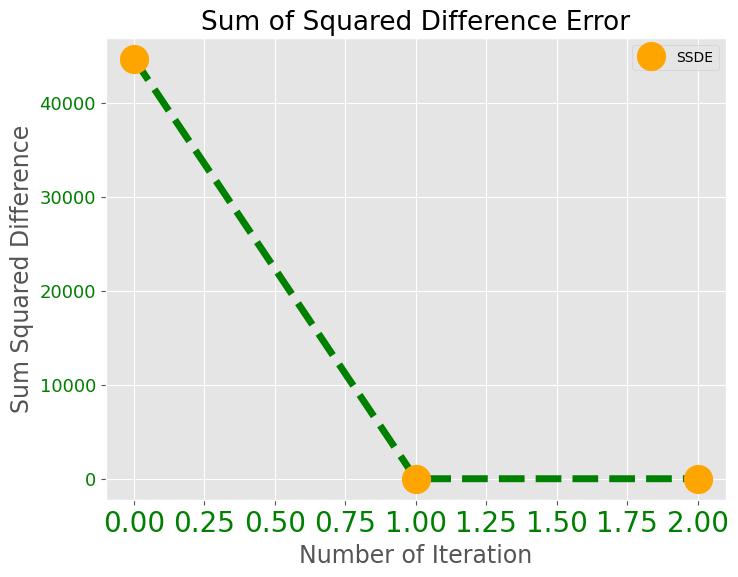

In [ ]:
plt.figure(figsize = (8,6),frameon = False)
plt.plot(pd.DataFrame(SSE_series),linestyle='dashed', linewidth=5,color = 'green')
plt.plot(pd.DataFrame(SSE_series),'o', markersize=20, color = 'orange', label = 'SSDE')
plt.xticks(color = 'green',size = 20)
plt.yticks(color = 'green',size = 13)
plt.xlabel('Number of Iteration',size = 17)
plt.ylabel('Sum Squared Difference',size = 17)
plt.title('Sum of Squared Difference Error',size = 19)
plt.legend()
#plt.savefig('SSDE.png')
plt.show()

## Annualized Volatility

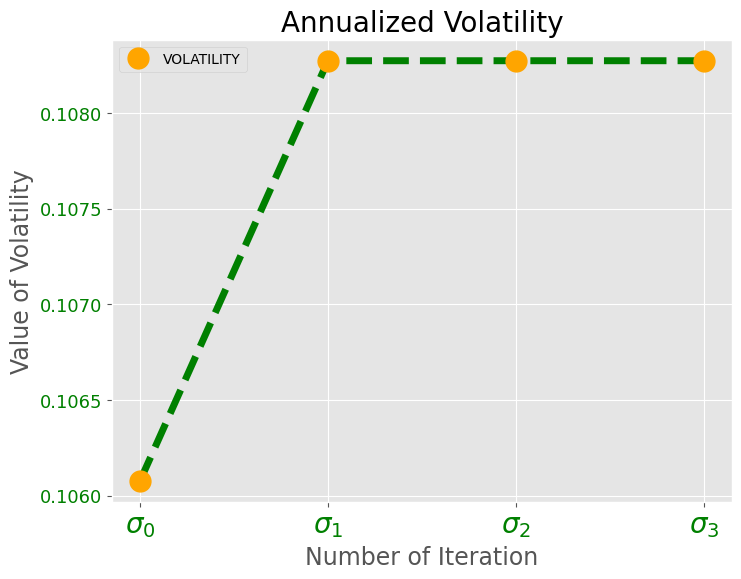

In [ ]:
labels_ = ('$\sigma_{0}$', '$\sigma_{1}$', '$\sigma_{2}$', \
           '$\sigma_{3}$')

plt.figure(figsize = (8,6))
plt.plot(asset_vol_series,linestyle='dashed', linewidth=5,color = 'green')
plt.plot(asset_vol_series,'o', markersize=15, label = 'VOLATILITY',color = 'orange')
plt.xticks(np.arange(4), labels_,color = 'green',size = 20)
plt.yticks(color = 'green',size = 13)
plt.xlabel('Number of Iteration',size = 17)
plt.ylabel('Value of Volatility', size = 17)
plt.title('Annualized Volatility',size = 20)
plt.legend(title_fontsize = 20)
#plt.savefig('volatility.png')
plt.show()

#  Usando CAPM (Capital Asset Pricing Model)para estimar la razón de drift $\mu$

Retornos

$returns = \frac{Current \ price - Previous \ price}{Previous\ price}$

Exceso de retornos


$excess$ $returns = returns - risk$ $free$


In [ ]:
# This dataframe contained risk free rate, S&P500, asset, last iterated asset
df_drift = data[['Risk_free','sp_500']]
df_drift['book_asset'] = asset_iteration_df[0].tolist()
df_drift['asset_iter'] = asset_iteration_df[2].tolist()


risk_free_rate = df_drift['Risk_free'].tolist()
rf = [i for i in risk_free_rate]

# S&P500
sp_500 = df_drift['sp_500'].tolist()
sp_500_ret = [(sp_500[i+1] - sp_500[i])/sp_500[i] for i in range(len(sp_500)-1)] # Compute daily returns for S&P500
sp_r1 = [i for i in sp_500_ret]
sp_excess_r1 = [i-j for i,j in zip(sp_r1,rf)]   # Compute excess return for S&P500
V_sp_excess_r1 = [i for i in sp_excess_r1]
V_sp_excess_r1.insert(0,np.nan) # Fill in nan value in order to match the size of assets in the dataframe below
sp_r1.insert(0,np.nan)    # Fill in nan value in order to match the size of S&p500 in the dataframe below

# Book asset
book_asset = df_drift['book_asset'].tolist()
book_asset_ret = [(book_asset[i+1] - book_asset[i])/book_asset[i] for i in range(len(book_asset)-1)]
ba_r2 = [i for i in book_asset_ret]
excess_ba_r2 = [i-j for i,j in zip(ba_r2,rf)]
V_excess_ba_r2 = [i for i in excess_ba_r2]
V_excess_ba_r2.insert(0,np.nan)
ba_r2.insert(0,np.nan)

# Asset Iterate
asset_iter = df_drift['asset_iter'].tolist()
asset_iter_ret = [(asset_iter[i+1] - asset_iter[i])/asset_iter[i] for i in range(len(asset_iter)-1)]
ait_r2 = [i for i in asset_iter_ret]
excess_ait_r2 = [i-j for i,j in zip(ait_r2,rf)]
V_excess_ait_r2 = [i for i in excess_ait_r2]
V_excess_ait_r2.insert(0,np.nan)
ait_r2.insert(0,np.nan)

# Dataframe
df_drift['sp_500_returns'] = sp_r1
df_drift['book_asset_ret'] = ba_r2
df_drift['asset_iter_ret'] = ait_r2
df_drift['V_sp_excess_r1'] = V_sp_excess_r1
df_drift['V_excess_ba_r2'] = V_excess_ba_r2
df_drift['V_excess_ait_r2'] = V_excess_ait_r2
df_drift


<ipython-input-20-e2117c7d066c>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_drift['book_asset'] = asset_iteration_df[0].tolist()


,Risk_free,sp_500,book_asset,asset_iter,sp_500_returns,book_asset_ret,asset_iter_ret,V_sp_excess_r1,V_excess_ba_r2,V_excess_ait_r2
2023-11-02,0.05270,4317.779785,467.103000,452.563198,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-03,0.05253,4358.339844,466.187656,451.692415,0.009394,-0.001960,-0.001924,-0.043306,-0.054660,-0.054624
2023-11-06,0.05260,4365.979980,468.754535,454.240947,0.001753,0.005506,0.005642,-0.050777,-0.047024,-0.046888
2023-11-07,0.05273,4378.379883,471.331348,456.783691,0.002840,0.005497,0.005598,-0.049760,-0.047103,-0.047002
2023-11-08,0.05268,4382.779785,472.395878,457.861325,0.001005,0.002259,0.002359,-0.051725,-0.050471,-0.050371
...,...,...,...,...,...,...,...,...,...,...
2024-10-28,0.04482,5823.520020,498.303994,486.940317,0.002651,0.004010,0.004244,-0.042449,-0.041090,-0.040856
2024-10-29,0.04480,5832.919922,498.573998,487.215174,0.001614,0.000542,0.000564,-0.043206,-0.044278,-0.044256
2024-10-30,0.04463,5813.669922,495.004006,483.686444,-0.003300,-0.007160,-0.007243,-0.048100,-0.051960,-0.052043
2024-10-31,0.04432,5705.450195,490.814004,479.571716,-0.018615,-0.008465,-0.008507,-0.063245,-0.053095,-0.053137


In [ ]:
excess_df = pd.DataFrame([sp_excess_r1,excess_ba_r2,excess_ait_r2]).T
excess_df.columns = ['excess_sp_500', 'excess_ba', 'excess_ait']
excess_df


,excess_sp_500,excess_ba,excess_ait
0,-0.043306,-0.054660,-0.054624
1,-0.050777,-0.047024,-0.046888
2,-0.049760,-0.047103,-0.047002
3,-0.051725,-0.050471,-0.050371
4,-0.060764,-0.053691,-0.053694
...,...,...,...
249,-0.042449,-0.041090,-0.040856
250,-0.043206,-0.044278,-0.044256
251,-0.048100,-0.051960,-0.052043
252,-0.063245,-0.053095,-0.053137


# Calcular Beta para los activos obtenidos con iteración y los originales

$Beta =$ $\frac{cov(excess_{sp\_500},\ excess_{asset})}{var(excess_{asset})}$

In [ ]:
# Calculate Beta from book asset and market index (S&P500)
cov_sp_ba = excess_df[['excess_sp_500','excess_ba']].cov()
Beta_sp_ba = cov_sp_ba.loc['excess_sp_500','excess_ba']/excess_df[['excess_sp_500']].var()
Beta_sp_ba = Beta_sp_ba.values[0]

# Calculate Beta from asset iterate and market index (S&P500)
cov_sp_ait = excess_df[['excess_sp_500','excess_ait']].cov()
Beta_sp_ait = cov_sp_ait.loc['excess_sp_500','excess_ait']/excess_df[['excess_sp_500']].var()
Beta_sp_ait = Beta_sp_ait.values[0]
(Beta_sp_ba,Beta_sp_ait)

(0.4904774843257047, 0.5021294339745357)

## Market premium

$Market$ $premium = E(return_{sp500})- risk$ $free$ $rate$

In [ ]:
# We convert the average daily return to average anualised daily returns:
E_Rm = (np.mean(sp_500_ret) + 1)**259 - 1

# average annualised market risk premium is assumed :
market_primium = E_Rm - rf[-1]
market_primium

0.3001533077830254

### Retornos esperados en book asset y asset iterativo
  
$expected_{returns} = risk$ $free$ $rate + beta\times Market$ $primium $

In [ ]:
#Expected return on book asset
expected_return_1 =  rf[-1] + (Beta_sp_ba * market_primium)
#Expected return on asset iterate
expected_return_2 =  rf[-1] + (Beta_sp_ait*market_primium)

(expected_return_1,expected_return_2)

(0.19121844026713158, 0.19471581149634945)

### Drift rate para book asset y asset iterativo

$Drift$ $rate = \ln(1 + expectd_{returns})$

In [ ]:
# drift rate of book asset
drift_1 = np.log(1+expected_return_1 )
# drift rate of asset iterate
drift_2 = np.log(1+expected_return_2 )

(drift_1,drift_2)

(0.17497668268014163, 0.1779083424536803)

## Tabla con el resumend del modelo CAPM

In [ ]:
capm_variable = {'At maturity 2020-02-06':['book asset', 'asset iterate'],
                 'Beta':[Beta_sp_ba,Beta_sp_ait],
                 'Expected return':[expected_return_1,expected_return_2],
                 'Drift rate': [drift_1,drift_2]}
pd.DataFrame(capm_variable)

,At maturity 2020-02-06,Beta,Expected return,Drift rate
0,book asset,0.490477,0.191218,0.174977
1,asset iterate,0.502129,0.194716,0.177908


# Calculando la probabilidad de default actual (APD, Actual Probability of Default) para book asset y asset iterativo
<br>

$P_{def} = N \left(- \frac{\ln\left(\frac{A_{T}}{L}\right)+ \left(\mu_{A} - \frac{\sigma_{A}}{2} \right)t}{\sigma_{A}\sqrt{t}} \right)$


In [ ]:
debt_last = debt[254]   # Debt at maturity

# Book asset
asset_1 = asset_iteration_df[0][254]  #Book asset at maturity
asset_1_vol = asset_vol_series[0]    #Book_asset's volatility at maturity
mu_1 = drift_1    #Drift rate at maturity

# Probability of default for Book asset
PD = st.norm.cdf(-((np.log(asset_1/debt_last) + (mu_1 - (asset_1_vol**2)*0.5)*T)/asset_1_vol*np.sqrt(T)))

# Asset iterate
asset_iter = asset_iteration_df[3][254]   # Asset_iterate at maturity
asset_iter_vol = asset_vol_series[3]    # Asset_iterate's volatility at maturity
mu_2 = drift_2   # Drift rate at maturity

#probability of default for Asset iterate
PD_iter = st.norm.cdf(-((np.log(asset_iter/debt_last) + (mu_1 - (asset_iter_vol**2)*0.5)*T)/asset_iter_vol*np.sqrt(T)))

str(round(PD*100,2))+'%', str(round(PD_iter*100,2))+'%'

<ipython-input-28-a5ab0cb795bb>:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  debt_last = debt[254]   # Debt at maturity


('0.0%', '0.0%')

Comparación de dos codigos que hacen los mismo, por el Warning que aparece en el cuadro de código anterior

In [ ]:
asset_iteration_df[3][254]

476.64946701415266

In [ ]:
asset_iteration_df.iloc[254,3]

476.64946701415266

In [ ]:
PD_variables = {'At maturity 2020-02-06' :['Debt ($L_{T}$)',
                                           'Asset ($A_{T}$)',
                                           'Volatility ($\sigma_{A}$)',
                                           'Drift rate ($\mu_{A}$)',
                                           ' ',
                                           'Probability of default ($PD$)'
                                          ],
                'Book asset':[debt_last, asset_1, str(round(asset_1_vol,2)) +'%', str(round(mu_1*100,2)) + '%', ' ', str(round(PD*100,2)) + '%'],
                'Asset iterate':[debt_last, asset_iter, str(round(asset_iter_vol,2)) +'%', str(round(mu_2*100,2)) +'%',' ', str(round(PD_iter*100,2)) + '%']}

pd.DataFrame(PD_variables)

,At maturity 2020-02-06,Book asset,Asset iterate
0,Debt ($L_{T}$),264.904,264.904
1,Asset ($A_{T}$),487.814004,476.649467
2,Volatility ($\sigma_{A}$),0.11%,0.11%
3,Drift rate ($\mu_{A}$),17.5%,17.79%
4,,,
5,Probability of default ($PD$),0.0%,0.0%


### Calculando la probabilidad de default neutral al riesgo (RNPD, Risk-Neutral Probability of default para book asset y asset iterativo


$P_{def} = N \left(- \frac{\ln\left(\frac{A_{T}}{L}\right)+ \left(r - \frac{\sigma_{A}}{2} \right)t}{\sigma_{A}\sqrt{t}} \right)$


In [ ]:
# RNPD for Book asset
RNPD = st.norm.cdf(-((np.log(asset_1/debt_last) + (rf[-1]  - (asset_1_vol**2)*0.5)*T)/asset_1_vol*np.sqrt(T)))

# RNPD for asset iterate
RNPD_iter = st.norm.cdf(-((np.log(asset_iter/debt_last) + (rf[-1] - (asset_iter_vol**2)*0.5)*T)/asset_iter_vol*np.sqrt(T)))

str(round(RNPD*100,2))+'%', str(round(RNPD_iter*100,2))+'%'


('0.0%', '0.0%')

In [ ]:
PD_variables = {'At maturity 2020-02-06' :['Debt ($L_{T}$)',
                                           'Asset ($A_{T}$)',
                                           'Volatility ($\sigma_{A}$)',
                                           'Risk-free rate ($Rf$)',
                                           ' ',
                                           'Risk-Neutral Probability of default ($RNPD$)'
                                          ],
                'Book asset':[debt_last, asset_1, str(round(asset_1_vol,2)) +'%', str(round(rf[-1]*100,2)) + '%', ' ', str(round(RNPD*100,2)) + '%'],
                'Asset iterate':[debt_last, asset_iter, str(round(asset_iter_vol,2)) +'%', str(round(rf[-1]*100,2)) +'%',' ', str(round(RNPD_iter*100,2)) + '%']}

pd.DataFrame(PD_variables)

,At maturity 2020-02-06,Book asset,Asset iterate
0,Debt ($L_{T}$),264.904,264.904
1,Asset ($A_{T}$),487.814004,476.649467
2,Volatility ($\sigma_{A}$),0.11%,0.11%
3,Risk-free rate ($Rf$),4.4%,4.4%
4,,,
5,Risk-Neutral Probability of default ($RNPD$),0.0%,0.0%


## Relación entre drift rate y probabilidad de Default

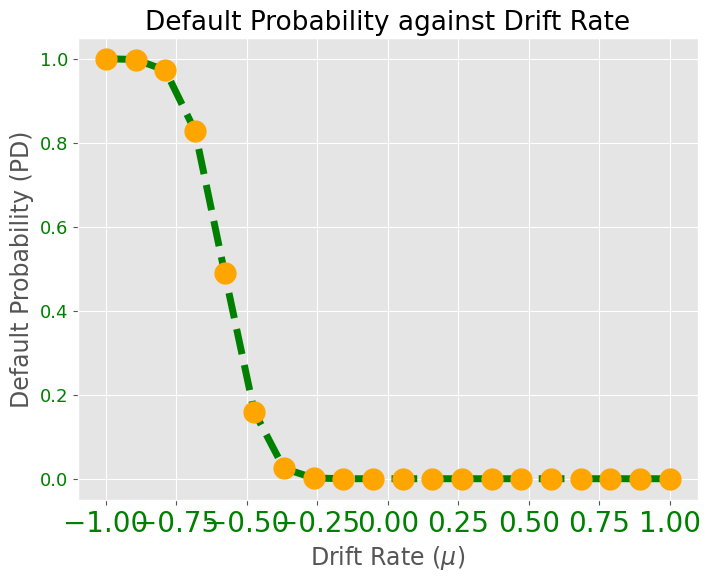

In [ ]:
drifts = np.linspace(-1,1,20)
rnpd = []
for drift in drifts:
    RNPD_iter = st.norm.cdf(-((np.log(asset_iter/debt_last) + (drift - (asset_iter_vol**2)*0.5)*T)/asset_iter_vol*np.sqrt(T)))
    rnpd.append(RNPD_iter)

# Visualization
plt.figure(figsize = (8,6),frameon = False)
plt.plot(drifts,rnpd,linestyle='dashed', linewidth=5,color = 'green')
plt.plot(drifts,rnpd,'o', markersize=15, color = 'orange', label = 'SSDE')
plt.xticks(color = 'green',size = 20)
plt.yticks(color = 'green',size = 13)
plt.xlabel('Drift Rate ($\mu$)',size = 17)
plt.ylabel('Default Probability (PD)',size = 17)
plt.title('Default Probability against Drift Rate',size = 19)
#plt.savefig('PDvsDrift.png')
plt.show()

# Referencias:

[Github](https://github.com/omomehinvictor/Credit-Risk/blob/master/Merton_CAPM_python.ipynb)